# Fault-Tolerant QEC: Steane \([[7,1,3]]\) and Bacon-Shor Codes

This notebook explores circuit-level and phenomenological simulations of quantum error correction protocols. We use `Stim` for fast Clifford simulation, `PyMatching` for MWPM decoding, and `Sinter` for parallelized benchmarking.

The goal is to benchmark the Steane \([[7,1,3]]\) color code and the Bacon-Shor subsystem code against physical baselines, investigate error amplification in unprotected transversal gates, and implement fault-tolerant state preparation (Goto 2016).

## 1. Steane \([[7,1,3]]\) Memory and Syndrome Extraction
We begin by defining the standard Steane code memory cycle. We use standard Hamming parity checks and implement relative detectors across multiple rounds to construct a spacetime decoding graph.

--- Single Round Steane Syndrome Extraction ---


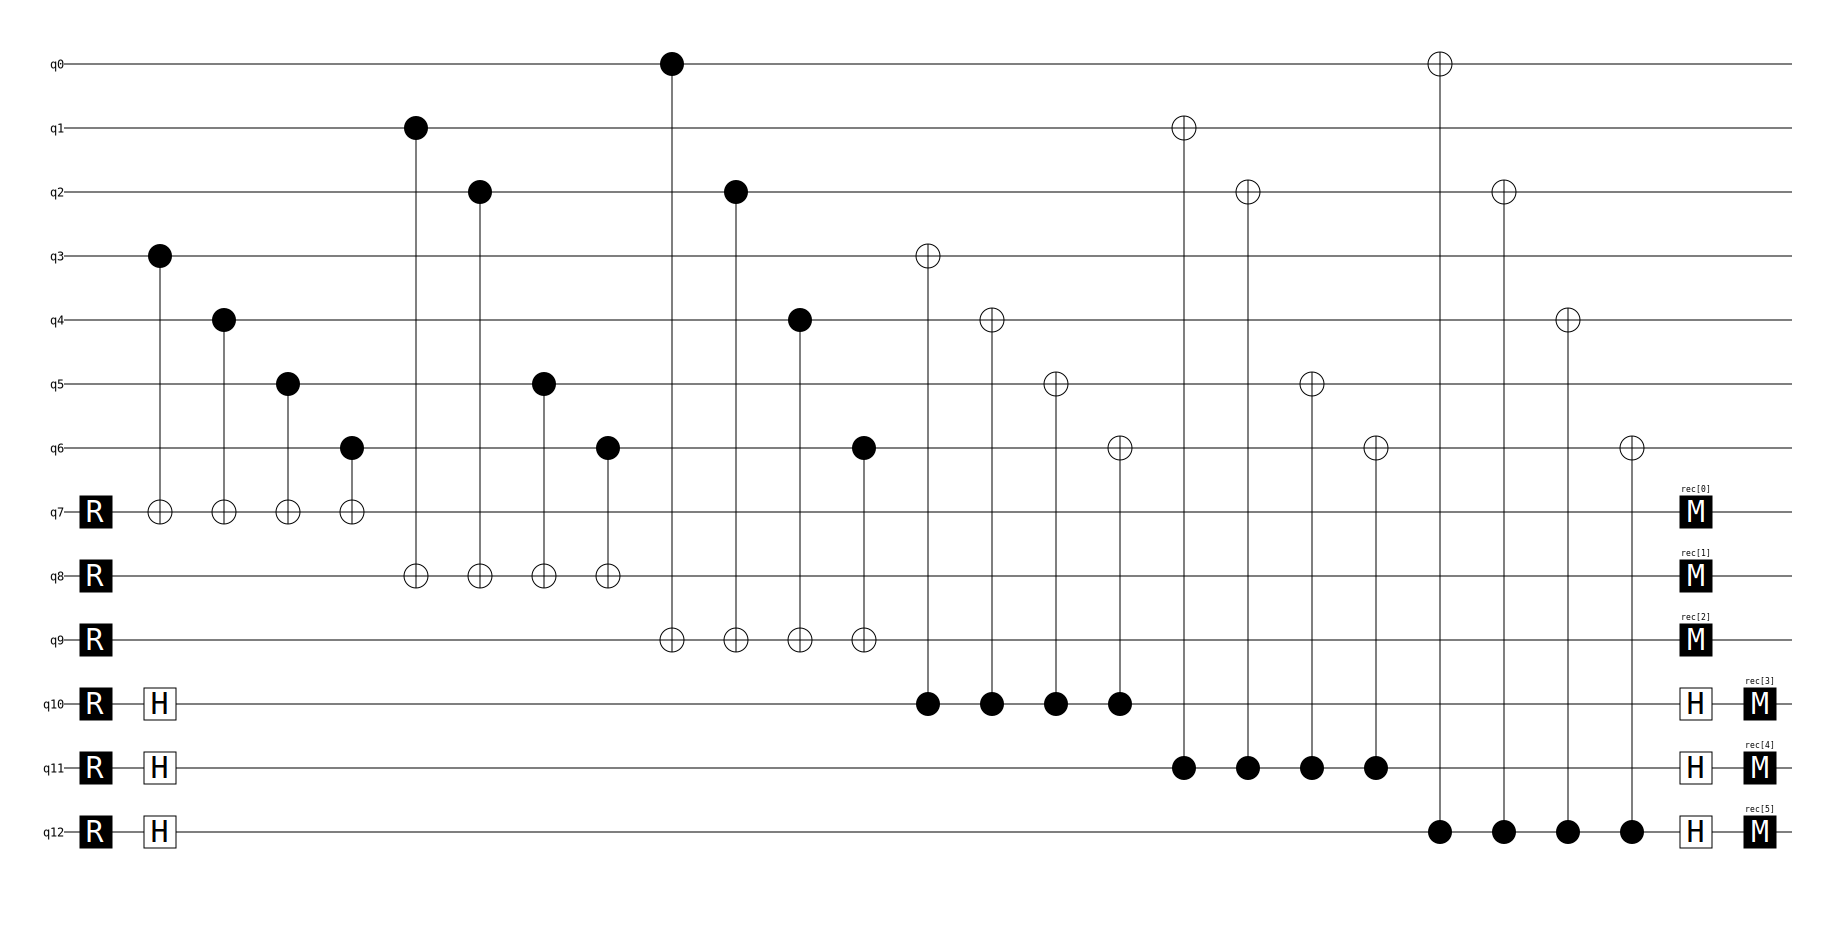


--- Steane Memory Circuit — 1 Round ---


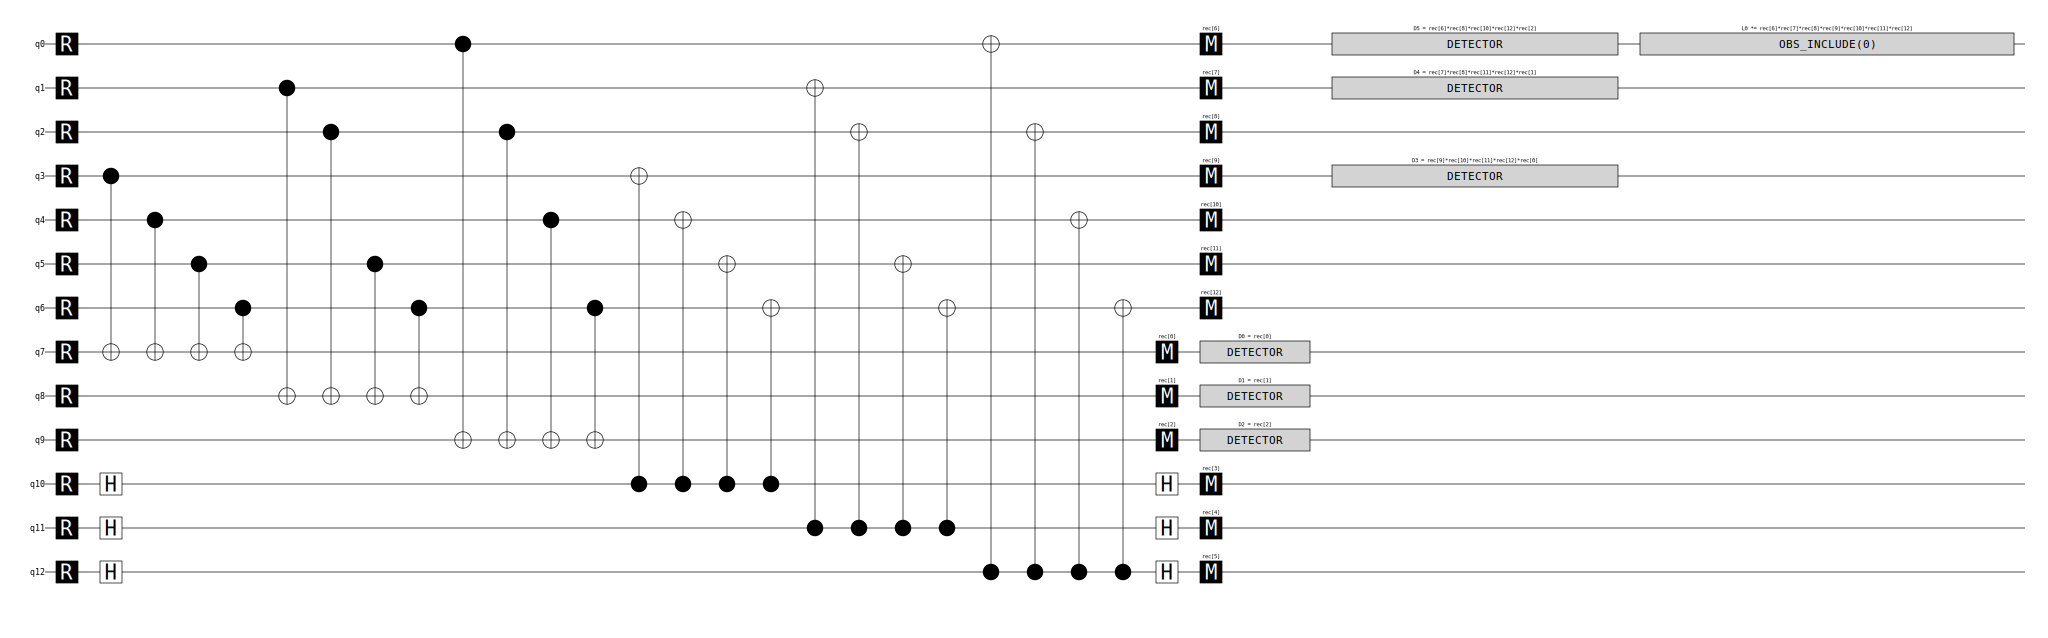


--- Steane Memory Circuit — 2 Rounds (Relative Detectors) ---


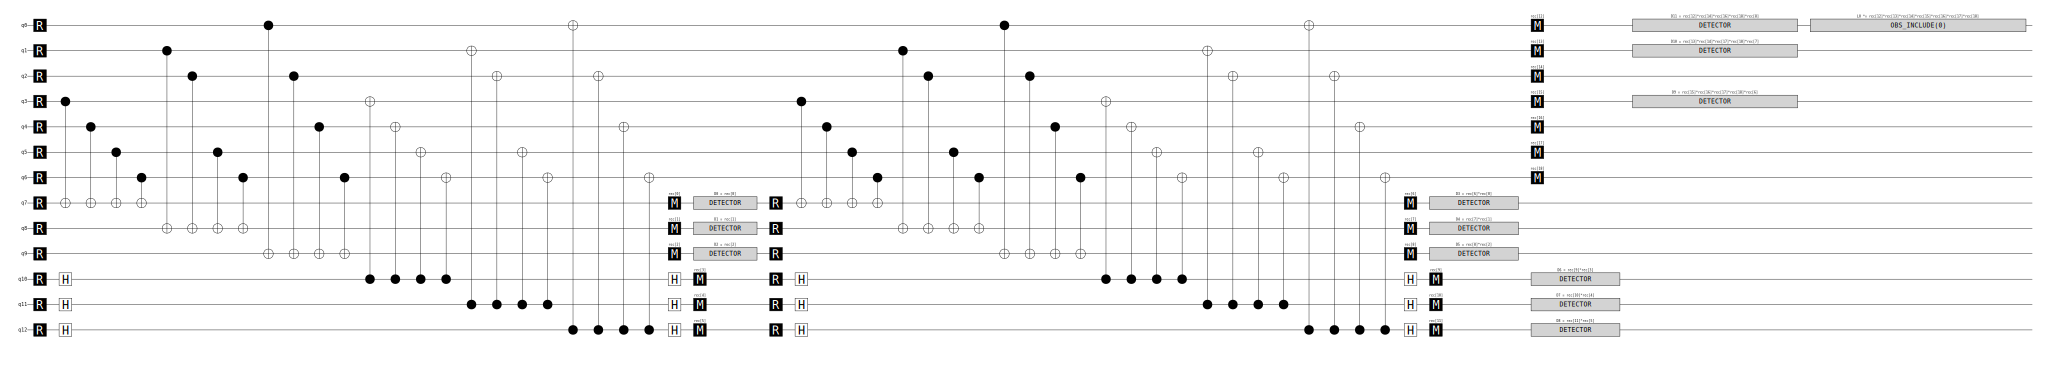


[+] Saved high-res SVGs to the current directory. Download them to view at full scale!


In [47]:
# CELL 1: Environment, Imports, and Steane QEC Builder
!pip install -q stim numpy matplotlib sinter pymatching

import stim
import numpy as np
import matplotlib.pyplot as plt

# Setup plot style for the notebook
plt.style.use('seaborn-v0_8-darkgrid')

def build_single_round_steane_syndrome() -> stim.Circuit:
    """One round of Steane syndrome extraction using standard Hamming parity checks."""
    c = stim.Circuit()
    c.append("R", [7, 8, 9, 10, 11, 12])
    c.append("H", [10, 11, 12])

    # Z stabilizers (detect X errors)
    c.append("CX", [3,7, 4,7, 5,7, 6,7])
    c.append("CX", [1,8, 2,8, 5,8, 6,8])
    c.append("CX", [0,9, 2,9, 4,9, 6,9])

    # X stabilizers (detect Z errors)
    c.append("CX", [10,3, 10,4, 10,5, 10,6])
    c.append("CX", [11,1, 11,2, 11,5, 11,6])
    c.append("CX", [12,0, 12,2, 12,4, 12,6])

    c.append("H", [10, 11, 12])
    c.append("M", [7, 8, 9, 10, 11, 12])
    return c

def build_steane_memory_circuit(num_rounds: int) -> stim.Circuit:
    """Builds Steane [[7,1,3]] memory circuit with relative detectors."""
    c = stim.Circuit()
    c.append("R", range(7))  # Initialize |0>_L

    for r in range(num_rounds):
        c += build_single_round_steane_syndrome()

        if r == 0:
            # Round 1: Only Z-syndromes are deterministic
            c.append("DETECTOR", [stim.target_rec(-6)])  # Z7
            c.append("DETECTOR", [stim.target_rec(-5)])  # Z8
            c.append("DETECTOR", [stim.target_rec(-4)])  # Z9
        else:
            # Subsequent rounds: compare to previous round (relative detectors)
            c.append("DETECTOR", [stim.target_rec(-6), stim.target_rec(-12)])  # Z7
            c.append("DETECTOR", [stim.target_rec(-5), stim.target_rec(-11)])  # Z8
            c.append("DETECTOR", [stim.target_rec(-4), stim.target_rec(-10)])  # Z9
            c.append("DETECTOR", [stim.target_rec(-3), stim.target_rec(-9)])   # X10
            c.append("DETECTOR", [stim.target_rec(-2), stim.target_rec(-8)])   # X11
            c.append("DETECTOR", [stim.target_rec(-1), stim.target_rec(-7)])   # X12

    # Final data measurement in Z basis
    c.append("M", range(7))

    # Boundary detectors: verify last Z-stabilizers using data qubits
    c.append("DETECTOR", [stim.target_rec(-4), stim.target_rec(-3), stim.target_rec(-2),
                          stim.target_rec(-1), stim.target_rec(-13)])  # Z7 (data 3,4,5,6)
    c.append("DETECTOR", [stim.target_rec(-6), stim.target_rec(-5), stim.target_rec(-2),
                          stim.target_rec(-1), stim.target_rec(-12)])  # Z8 (data 1,2,5,6)
    c.append("DETECTOR", [stim.target_rec(-7), stim.target_rec(-5), stim.target_rec(-3),
                          stim.target_rec(-1), stim.target_rec(-11)])  # Z9 (data 0,2,4,6)

    # Logical observable: Z_L parity
    obs_targets = [stim.target_rec(-7 + i) for i in range(7)]
    c.append("OBSERVABLE_INCLUDE", obs_targets, 0)

    return c

# --- SVG Diagrams & Saving ---

# Generate the diagram objects
diag_syndrome = build_single_round_steane_syndrome().diagram("timeline-svg")
diag_mem_1 = build_steane_memory_circuit(1).diagram("timeline-svg")
diag_mem_2 = build_steane_memory_circuit(2).diagram("timeline-svg")

# Write them to files so they can be downloaded and zoomed
with open("steane_syndrome.svg", "w") as f:
    print(diag_syndrome, file=f)
with open("steane_memory_1_round.svg", "w") as f:
    print(diag_mem_1, file=f)
with open("steane_memory_2_rounds.svg", "w") as f:
    print(diag_mem_2, file=f)

# Display them inline
print("--- Single Round Steane Syndrome Extraction ---")
display(diag_syndrome)

print("\n--- Steane Memory Circuit — 1 Round ---")
display(diag_mem_1)

print("\n--- Steane Memory Circuit — 2 Rounds (Relative Detectors) ---")
display(diag_mem_2)


In [48]:
# CELL 2: Circuit-Level Hardware Noise Model
class NoiseModel:
    def __init__(self, scale: float = 1.0):
        self.init_error   = scale * 1.66e-6
        self.meas_error   = scale * 2.4e-3
        self.depolarize1  = scale * 7e-5
        self.depolarize2  = scale * 3.1e-3

    def apply(self, c: stim.Circuit) -> stim.Circuit:
        cn = stim.Circuit()
        for op in c:
            name = op.name
            targets = op.targets_copy()
            args = op.gate_args_copy()

            if name == "CX":
                cn.append("CX", targets)
                if self.depolarize2 > 0:
                    cn.append("DEPOLARIZE2", targets, self.depolarize2)
                continue

            if name == "M" and self.meas_error > 0:
                # Note: X_ERROR must be injected immediately prior to the M instruction
                # in order to properly simulate a readout bit-flip in Stim.
                cn.append("X_ERROR", targets, self.meas_error)

            cn.append(name, targets, args)

            if name in ["H", "X", "Y", "S", "S_DAG", "I"] and self.depolarize1 > 0:
                cn.append("DEPOLARIZE1", targets, self.depolarize1)
            if name == "R" and self.init_error > 0:
                cn.append("X_ERROR", targets, self.init_error)

        return cn


--- Noisy Steane Memory Circuit (1 round) ---
Includes depolarizing + measurement noise


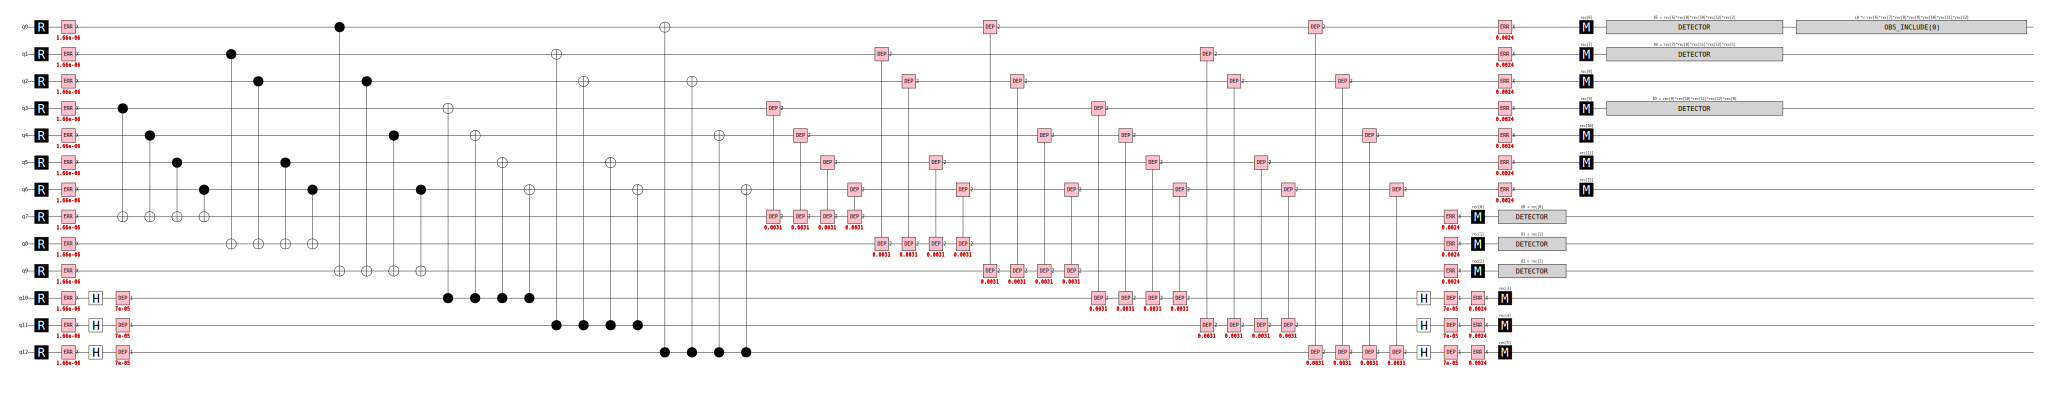

In [49]:
# Generate the noisy circuit and its diagram
noisy_circuit = NoiseModel(scale=1.0).apply(build_steane_memory_circuit(1))
diag_noisy = noisy_circuit.diagram("timeline-svg")

# Save the SVG for high-res viewing
with open("noisy_steane_memory_1_round.svg", "w") as f:
    print(diag_noisy, file=f)

# Display inline
print("\n--- Noisy Steane Memory Circuit (1 round) ---")
print("Includes depolarizing + measurement noise")
display(diag_noisy)

### Circuit-Level Noise and Baseline Benchmarking
To test the Steane memory, we apply a custom circuit-level noise model (parameterized by a `scale` factor relative to a trapped-ion/Quantinuum baseline) consisting of depolarizing and measurement errors.

We benchmark the logical memory against a fair physical baseline: a single unencoded physical qubit idling for the same number of clock cycles as the QEC rounds. Without fault-tolerant state preparation or flag qubits, bare-ancilla hook errors will likely dominate at higher noise scales.

--- Building Sinter Tasks ---
Created 14 tasks.

--- Starting PyMatching Sweep ---

--- Sweep Results ---
Type                         Scale    Shots   Errors Logical Error Rate
---------------------------------------------------------------------------
Physical (Unencoded)          2.15    50000      536            0.01072
Physical (Unencoded)          1.00    50000      215            0.00430
Steane [[7,1,3]]              4.64     5393     1078            0.19989
Physical (Unencoded)          4.64    44305     1000            0.02257
Steane [[7,1,3]]             10.00     3345     1078            0.32227
Physical (Unencoded)         10.00    20753     1009            0.04862
Physical (Unencoded)         21.54    10513     1081            0.10283
Steane [[7,1,3]]             21.54     2321     1086            0.46790
Steane [[7,1,3]]             46.42     2321     1173            0.50539
Physical (Unencoded)         46.42     5393     1064            0.19729
Physical (Unencoded)      

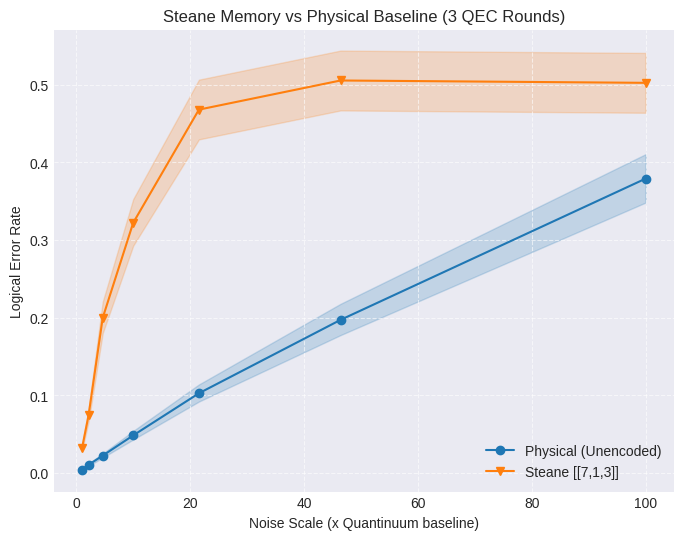

In [50]:
# CELL 3: Steane Memory Benchmark using Sinter and PyMatching

import sinter

def physical_memory_circuit(num_rounds: int) -> stim.Circuit:
    """
    Fair physical qubit baseline: one idle cycle per logical round.
    Includes a dummy detector so PyMatching can compile without throwing an error.
    """
    c = stim.Circuit()
    c.append("R", [0])
    for _ in range(num_rounds):
        c.append("I", [0])          # Generic idle operation representing the round length
        c.append("TICK")
    c.append("M", [0])              # Final data measurement
    c.append("M", [0])              # Dummy measurement
    c.append("DETECTOR", [stim.target_rec(-1), stim.target_rec(-2)])
    c.append("OBSERVABLE_INCLUDE", [stim.target_rec(-1)], 0)
    return c

# --- Configuration ---
num_rounds = 3
scales = np.logspace(0, 2, 7)
tasks = []

print("--- Building Sinter Tasks ---")
for scale in scales:
    noise = NoiseModel(scale)

    # Task 1: Steane logical memory
    c_steane = noise.apply(build_steane_memory_circuit(num_rounds))
    tasks.append(sinter.Task(
        circuit=c_steane,
        json_metadata={'scale': scale, 'type': 'Steane [[7,1,3]]'}
    ))

    # Task 2: Physical qubit reference
    c_phys = noise.apply(physical_memory_circuit(num_rounds))
    tasks.append(sinter.Task(
        circuit=c_phys,
        json_metadata={'scale': scale, 'type': 'Physical (Unencoded)'}
    ))

print(f"Created {len(tasks)} tasks.")
print("\n--- Starting PyMatching Sweep ---")
print("Collecting stats... (this usually takes 30-90 seconds)\n")

stats = sinter.collect(
    num_workers=4,
    tasks=tasks,
    decoders=['pymatching'],
    max_shots=50_000,
    max_errors=1000
)

# --- Diagnostics & Results ---
print("--- Sweep Results ---")
print(f"{'Type':<25} {'Scale':>8} {'Shots':>8} {'Errors':>8} {'Logical Error Rate':>18}")
print("-" * 75)

for stat in stats:
    typ   = stat.json_metadata['type']
    scale = stat.json_metadata['scale']
    rate  = stat.errors / stat.shots if stat.shots > 0 else 0
    print(f"{typ:<25} {scale:8.2f} {stat.shots:8d} {stat.errors:8d} {rate:18.5f}")

print("\nNote: Bare-ancilla hook errors dominate at higher noise scales. We only expect the")
print("Steane memory to beat the physical baseline at very low noise (if at all) without flag EC.")

# --- Plotting & Saving ---
fig, ax = plt.subplots(1, 1, figsize=(8, 6))

sinter.plot_error_rate(
    ax=ax,
    stats=stats,
    x_func=lambda s: s.json_metadata['scale'],
    group_func=lambda s: s.json_metadata['type']
)

ax.set_xlabel("Noise Scale (x Quantinuum baseline)")
ax.set_ylabel("Logical Error Rate")
ax.set_title(f"Steane Memory vs Physical Baseline ({num_rounds} QEC Rounds)")
ax.grid(which='both', ls='--', alpha=0.6)
ax.legend()

# Save the plot BEFORE plt.show()
plt.savefig("steane_vs_physical_threshold.png", dpi=300, bbox_inches="tight")

plt.show()

## 2. Transversal Logical Gates and Error Amplification
A major advantage of CSS codes like Steane is that CNOT, H, and Pauli gates are transversal. Here, we demonstrate logical algorithms—specifically preparing a 3-qubit logical GHZ state and running a logical Bernstein-Vazirani circuit.

Because we do not interleave syndrome extraction rounds between these logical operations, we expect to see raw error amplification rather than suppression. This serves as a baseline for the necessity of FT operations.

--- Logical GHZ Circuit (Transversal on 3 Steane blocks) ---


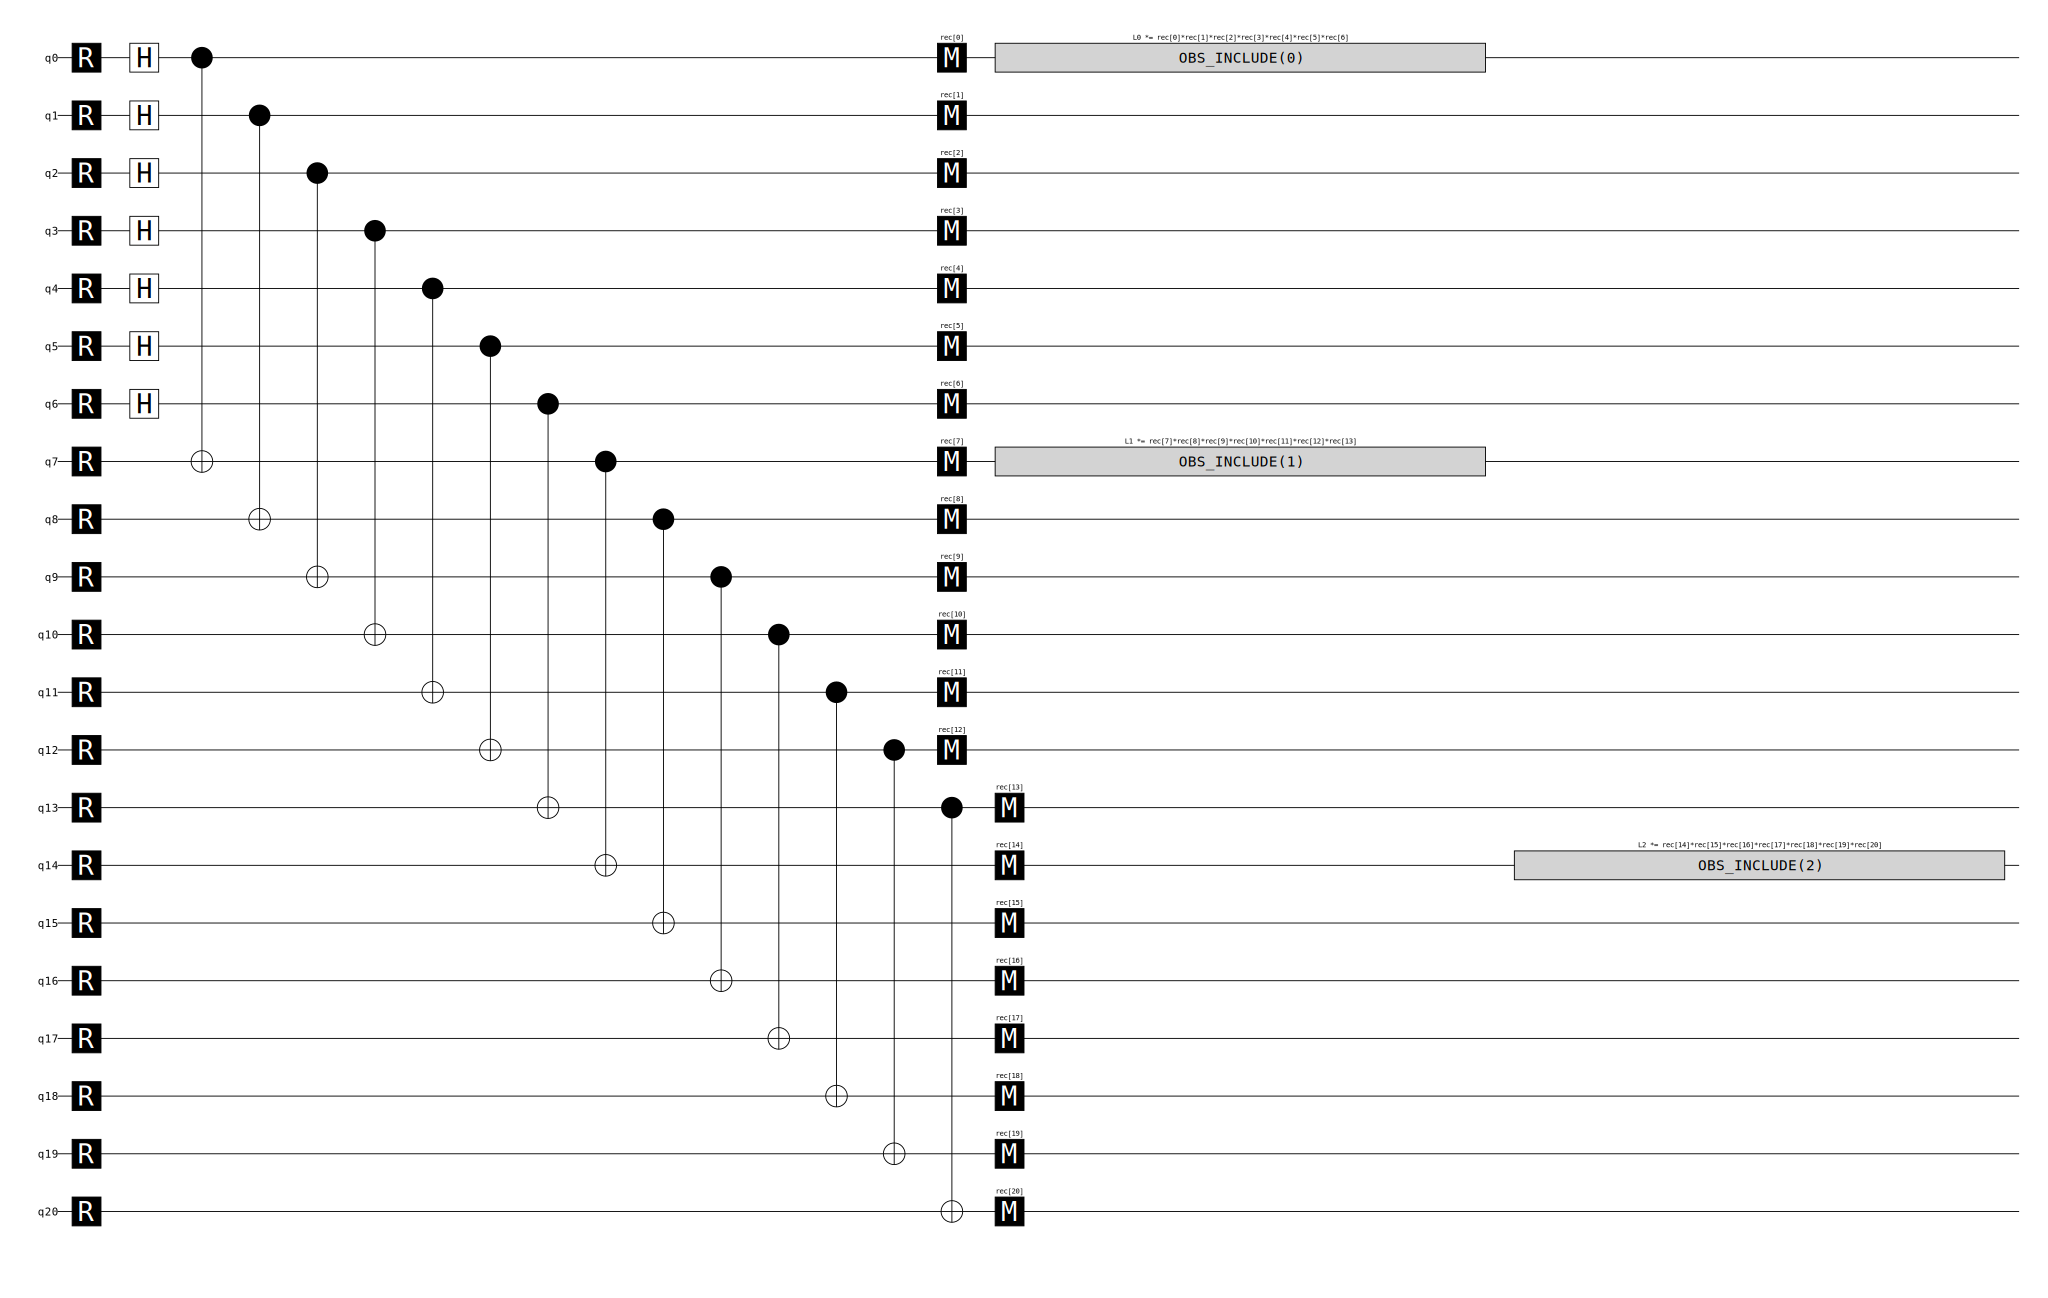


[+] Saved high-res SVG to 'transversal_ghz_circuit.svg'


In [51]:
# CELL 4: Transversal Logical GHZ Circuit (Uncorrected)

def build_logical_ghz_transversal_circuit() -> stim.Circuit:
    """
    Prepares a logical 3-qubit GHZ state using transversal gates across 3 Steane blocks.
    No intermediate EC is performed, serving as a baseline for error amplification.
    """
    c = stim.Circuit()
    c.append("R", range(21))                    # 3 logical blocks, 7 data qubits each

    # Prepare logical |+>_L on the first block (qubits 0-6)
    c.append("H", range(7))

    # Transversal CNOT: block 0 (control) -> block 1 (target)
    for i in range(7):
        c.append("CX", [i, i + 7])

    # Transversal CNOT: block 1 (control) -> block 2 (target)
    for i in range(7):
        c.append("CX", [i + 7, i + 14])

    # Measure all 21 data qubits in the Z-basis
    c.append("M", range(21))

    # Logical observables: Z_L parity for each of the three blocks
    c.append("OBSERVABLE_INCLUDE", [stim.target_rec(-21 + i) for i in range(7)], 0)
    c.append("OBSERVABLE_INCLUDE", [stim.target_rec(-14 + i) for i in range(7)], 1)
    c.append("OBSERVABLE_INCLUDE", [stim.target_rec(-7  + i) for i in range(7)], 2)

    return c

# --- Generate and Save SVG Diagram ---
ghz_circuit = build_logical_ghz_transversal_circuit()
diag_ghz = ghz_circuit.diagram("timeline-svg")

# Save to file for high-res downloading
with open("transversal_ghz_circuit.svg", "w") as f:
    print(diag_ghz, file=f)

print("--- Logical GHZ Circuit (Transversal on 3 Steane blocks) ---")
display(diag_ghz)

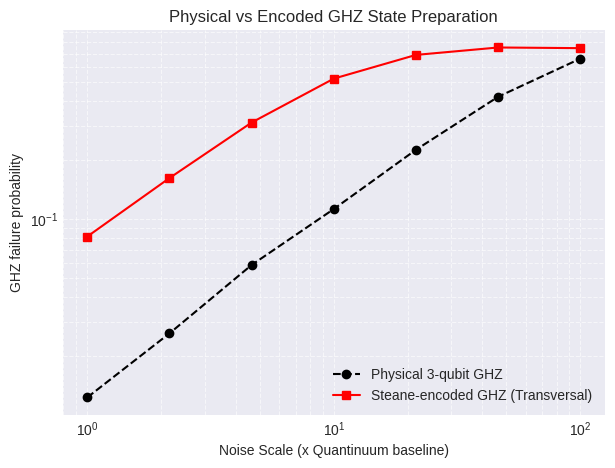

In [39]:
# CELL 5: Logical GHZ State Preparation Benchmark
import numpy as np
import matplotlib.pyplot as plt

def sim_logical_ghz(scale: float, shots: int = 20_000):
    """Simulate logical GHZ failure probability using the circuit-level NoiseModel."""
    c = build_logical_ghz_transversal_circuit()
    noisy = NoiseModel(scale).apply(c)
    sampler = noisy.compile_sampler()
    samples = sampler.sample(shots=shots)

    # A logical GHZ state should yield identical Z_L parities across all 3 logical qubits.
    # Failure = any of the three logical Z parities disagree
    n = samples.shape[1]
    p0 = np.sum(samples[:, n-21:n-14], axis=1) % 2
    p1 = np.sum(samples[:, n-14:n-7],  axis=1) % 2
    p2 = np.sum(samples[:, n-7:n],     axis=1) % 2

    errors = np.sum((p0 != p1) | (p0 != p2))
    return errors / shots


# --- Physical 3-qubit GHZ reference ---
def physical_ghz_circuit() -> stim.Circuit:
    """Standard unencoded 3-qubit GHZ state preparation."""
    c = stim.Circuit()
    c.append("R", [0, 1, 2])
    c.append("H", [0])
    c.append("CX", [0, 1])
    c.append("CX", [1, 2])
    c.append("M", [0, 1, 2])
    return c

def sim_physical_ghz(scale: float, shots: int = 20_000):
    noisy = NoiseModel(scale).apply(physical_ghz_circuit())
    s = noisy.compile_sampler().sample(shots=shots)
    # Physical failure = any of the 3 qubits disagree in the Z-basis
    return sum(1 for row in s if not (row[0] == row[1] == row[2])) / shots


# --- Run Sweep and Plot ---
scales = np.logspace(0, 2, 7)
log_ghz = [sim_logical_ghz(s) for s in scales]
phys_ghz = [sim_physical_ghz(s) for s in scales]

plt.figure(figsize=(7, 5))
plt.loglog(scales, phys_ghz, 'k--o', label='Physical 3-qubit GHZ')
plt.loglog(scales, log_ghz, 'r-s', label='Steane-encoded GHZ (Transversal)')
plt.xlabel("Noise Scale (x Quantinuum baseline)")
plt.ylabel("GHZ failure probability")
plt.title("Physical vs Encoded GHZ State Preparation")
plt.grid(which='both', ls='--', alpha=0.6)
plt.legend()
plt.show()

## 3. Subsystem Codes: Bacon-Shor Phenomenological Thresholds
We now shift to the Bacon-Shor subsystem code. Unlike the Steane code, Bacon-Shor does not require measuring full stabilizer generators; we only measure 2-qubit gauge operators, making it highly suitable for 2D nearest-neighbor architectures.

To efficiently evaluate the threshold scaling up to \(d=9\), we implement a custom noise injector that parses noiseless Stim circuits and injects phenomenological errors (\(X\), \(Z\), and depolarizing) based on a physical error rate \(p\).

Running PyMatching sweep for d=3, 5, 7, 9...


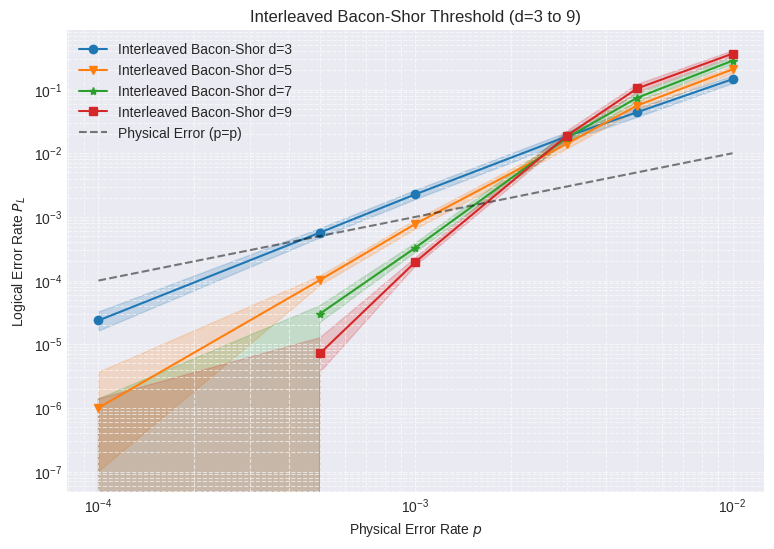

In [40]:
# CELL 6: Interleaved Bacon-Shor Phenomenological Threshold (d=3, 5, 7, 9)
import stim
import sinter
import matplotlib.pyplot as plt
import multiprocessing
import os

# --- 1. LOAD CIRCUITS ---
# Small distance circuits kept inline; larger circuits loaded from disk
circuit_d3_str = """
QUBIT_COORDS(0, 0) 0
QUBIT_COORDS(0, 1) 1
QUBIT_COORDS(0, 2) 2
QUBIT_COORDS(1, 0) 3
QUBIT_COORDS(1, 1) 4
QUBIT_COORDS(1, 2) 5
QUBIT_COORDS(2, 0) 6
QUBIT_COORDS(2, 1) 7
QUBIT_COORDS(2, 2) 8
TICK
R 0 1 2 3 4 5 6 7 8
TICK
TICK
MZZ 0 1 3 4 6 7
DETECTOR(0, 0, 0) rec[-3]
DETECTOR(1, 0, 0) rec[-2]
DETECTOR(2, 0, 0) rec[-1]
TICK
MXX 0 3 1 4 2 5
TICK
MZZ 1 2 4 5 7 8
DETECTOR(2, 1, 1) rec[-3] rec[-2] rec[-1]
TICK
MXX 3 6 4 7 5 8
TICK
TICK
MZZ 0 1 3 4 6 7
DETECTOR(2, 0, 2) rec[-3] rec[-2] rec[-1] rec[-15] rec[-14] rec[-13]
TICK
MXX 0 3 1 4 2 5
DETECTOR(0, 2, 3) rec[-3] rec[-2] rec[-1] rec[-15] rec[-14] rec[-13]
TICK
MZZ 1 2 4 5 7 8
DETECTOR(2, 1, 4) rec[-3] rec[-2] rec[-1] rec[-15] rec[-14] rec[-13]
TICK
MXX 3 6 4 7 5 8
DETECTOR(1, 2, 5) rec[-3] rec[-2] rec[-1] rec[-15] rec[-14] rec[-13]
TICK
TICK
MZZ 0 1 3 4 6 7
DETECTOR(2, 0, 6) rec[-3] rec[-2] rec[-1] rec[-15] rec[-14] rec[-13]
TICK
MXX 0 3 1 4 2 5
DETECTOR(0, 2, 7) rec[-3] rec[-2] rec[-1] rec[-15] rec[-14] rec[-13]
TICK
MZZ 1 2 4 5 7 8
DETECTOR(2, 1, 8) rec[-3] rec[-2] rec[-1] rec[-15] rec[-14] rec[-13]
TICK
MXX 3 6 4 7 5 8
DETECTOR(1, 2, 9) rec[-3] rec[-2] rec[-1] rec[-15] rec[-14] rec[-13]
TICK
TICK
M 0 1 2 3 4 5 6 7 8
DETECTOR(2, 0, 10) rec[-9] rec[-8] rec[-6] rec[-5] rec[-3] rec[-2] rec[-21] rec[-20] rec[-19]
DETECTOR(2, 1, 10) rec[-8] rec[-7] rec[-5] rec[-4] rec[-2] rec[-1] rec[-15] rec[-14] rec[-13]
OBSERVABLE_INCLUDE(0) rec[-7] rec[-4] rec[-1]
"""

circuit_d5_str = """
QUBIT_COORDS(0, 0) 0
QUBIT_COORDS(0, 1) 1
QUBIT_COORDS(0, 2) 2
QUBIT_COORDS(0, 3) 3
QUBIT_COORDS(0, 4) 4
QUBIT_COORDS(1, 0) 5
QUBIT_COORDS(1, 1) 6
QUBIT_COORDS(1, 2) 7
QUBIT_COORDS(1, 3) 8
QUBIT_COORDS(1, 4) 9
QUBIT_COORDS(2, 0) 10
QUBIT_COORDS(2, 1) 11
QUBIT_COORDS(2, 2) 12
QUBIT_COORDS(2, 3) 13
QUBIT_COORDS(2, 4) 14
QUBIT_COORDS(3, 0) 15
QUBIT_COORDS(3, 1) 16
QUBIT_COORDS(3, 2) 17
QUBIT_COORDS(3, 3) 18
QUBIT_COORDS(3, 4) 19
QUBIT_COORDS(4, 0) 20
QUBIT_COORDS(4, 1) 21
QUBIT_COORDS(4, 2) 22
QUBIT_COORDS(4, 3) 23
QUBIT_COORDS(4, 4) 24
TICK
R 0 1 2 3 4 5 6 7 8 9 10 11 12 13 14 15 16 17 18 19 20 21 22 23 24
TICK
TICK
MZZ 0 1 5 6 10 11 15 16 20 21 2 3 7 8 12 13 17 18 22 23
DETECTOR(0, 0, 0) rec[-10]
DETECTOR(1, 0, 0) rec[-9]
DETECTOR(2, 0, 0) rec[-8]
DETECTOR(3, 0, 0) rec[-7]
DETECTOR(4, 0, 0) rec[-6]
DETECTOR(0, 2, 0) rec[-5]
DETECTOR(1, 2, 0) rec[-4]
DETECTOR(2, 2, 0) rec[-3]
DETECTOR(3, 2, 0) rec[-2]
DETECTOR(4, 2, 0) rec[-1]
TICK
MXX 0 5 1 6 2 7 3 8 4 9 10 15 11 16 12 17 13 18 14 19
TICK
MZZ 1 2 6 7 11 12 16 17 21 22 3 4 8 9 13 14 18 19 23 24
DETECTOR(4, 1, 1) rec[-6] rec[-7] rec[-8] rec[-9] rec[-10]
DETECTOR(4, 3, 1) rec[-1] rec[-2] rec[-3] rec[-4] rec[-5]
TICK
MXX 5 10 6 11 7 12 8 13 9 14 15 20 16 21 17 22 18 23 19 24
TICK
TICK
MZZ 0 1 5 6 10 11 15 16 20 21 2 3 7 8 12 13 17 18 22 23
DETECTOR(4, 0, 2) rec[-6] rec[-7] rec[-8] rec[-9] rec[-10] rec[-46] rec[-47] rec[-48] rec[-49] rec[-50]
DETECTOR(4, 2, 2) rec[-1] rec[-2] rec[-3] rec[-4] rec[-5] rec[-41] rec[-42] rec[-43] rec[-44] rec[-45]
TICK
MXX 0 5 1 6 2 7 3 8 4 9 10 15 11 16 12 17 13 18 14 19
DETECTOR(0, 4, 3) rec[-6] rec[-7] rec[-8] rec[-9] rec[-10] rec[-46] rec[-47] rec[-48] rec[-49] rec[-50]
DETECTOR(2, 4, 3) rec[-1] rec[-2] rec[-3] rec[-4] rec[-5] rec[-41] rec[-42] rec[-43] rec[-44] rec[-45]
TICK
MZZ 1 2 6 7 11 12 16 17 21 22 3 4 8 9 13 14 18 19 23 24
DETECTOR(4, 1, 4) rec[-6] rec[-7] rec[-8] rec[-9] rec[-10] rec[-46] rec[-47] rec[-48] rec[-49] rec[-50]
DETECTOR(4, 3, 4) rec[-1] rec[-2] rec[-3] rec[-4] rec[-5] rec[-41] rec[-42] rec[-43] rec[-44] rec[-45]
TICK
MXX 5 10 6 11 7 12 8 13 9 14 15 20 16 21 17 22 18 23 19 24
DETECTOR(1, 4, 5) rec[-6] rec[-7] rec[-8] rec[-9] rec[-10] rec[-46] rec[-47] rec[-48] rec[-49] rec[-50]
DETECTOR(3, 4, 5) rec[-1] rec[-2] rec[-3] rec[-4] rec[-5] rec[-41] rec[-42] rec[-43] rec[-44] rec[-45]
TICK
TICK
MZZ 0 1 5 6 10 11 15 16 20 21 2 3 7 8 12 13 17 18 22 23
DETECTOR(4, 0, 6) rec[-6] rec[-7] rec[-8] rec[-9] rec[-10] rec[-46] rec[-47] rec[-48] rec[-49] rec[-50]
DETECTOR(4, 2, 6) rec[-1] rec[-2] rec[-3] rec[-4] rec[-5] rec[-41] rec[-42] rec[-43] rec[-44] rec[-45]
TICK
MXX 0 5 1 6 2 7 3 8 4 9 10 15 11 16 12 17 13 18 14 19
DETECTOR(0, 4, 7) rec[-6] rec[-7] rec[-8] rec[-9] rec[-10] rec[-46] rec[-47] rec[-48] rec[-49] rec[-50]
DETECTOR(2, 4, 7) rec[-1] rec[-2] rec[-3] rec[-4] rec[-5] rec[-41] rec[-42] rec[-43] rec[-44] rec[-45]
TICK
MZZ 1 2 6 7 11 12 16 17 21 22 3 4 8 9 13 14 18 19 23 24
DETECTOR(4, 1, 8) rec[-6] rec[-7] rec[-8] rec[-9] rec[-10] rec[-46] rec[-47] rec[-48] rec[-49] rec[-50]
DETECTOR(4, 3, 8) rec[-1] rec[-2] rec[-3] rec[-4] rec[-5] rec[-41] rec[-42] rec[-43] rec[-44] rec[-45]
TICK
MXX 5 10 6 11 7 12 8 13 9 14 15 20 16 21 17 22 18 23 19 24
DETECTOR(1, 4, 9) rec[-6] rec[-7] rec[-8] rec[-9] rec[-10] rec[-46] rec[-47] rec[-48] rec[-49] rec[-50]
DETECTOR(3, 4, 9) rec[-1] rec[-2] rec[-3] rec[-4] rec[-5] rec[-41] rec[-42] rec[-43] rec[-44] rec[-45]
TICK
TICK
M 0 1 2 3 4 5 6 7 8 9 10 11 12 13 14 15 16 17 18 19 20 21 22 23 24
DETECTOR(4, 0, 10) rec[-4] rec[-5] rec[-9] rec[-10] rec[-14] rec[-15] rec[-19] rec[-20] rec[-24] rec[-25] rec[-61] rec[-62] rec[-63] rec[-64] rec[-65]
DETECTOR(4, 1, 10) rec[-3] rec[-4] rec[-8] rec[-9] rec[-13] rec[-14] rec[-18] rec[-19] rec[-23] rec[-24] rec[-41] rec[-42] rec[-43] rec[-44] rec[-45]
DETECTOR(4, 2, 10) rec[-2] rec[-3] rec[-7] rec[-8] rec[-12] rec[-13] rec[-17] rec[-18] rec[-22] rec[-23] rec[-56] rec[-57] rec[-58] rec[-59] rec[-60]
DETECTOR(4, 3, 10) rec[-1] rec[-2] rec[-6] rec[-7] rec[-11] rec[-12] rec[-16] rec[-17] rec[-21] rec[-22] rec[-36] rec[-37] rec[-38] rec[-39] rec[-40]
OBSERVABLE_INCLUDE(0) rec[-5] rec[-10] rec[-15] rec[-20] rec[-25]
"""

# Replace comments to ensure compatibility with stim parser
with open("bacon_shor_d7.stim", "r") as f:
    circuit_d7_str = f.read().replace("//", "#")

with open("bacon_shor_d9.stim", "r") as f:
    circuit_d9_str = f.read().replace("//", "#")

# --- 2. ROBUST NOISE INJECTOR ---
def inject_phenomenological_noise(base_str: str, p: float) -> stim.Circuit:
    """Parses a noiseless Stim circuit string and injects depolarizing & measurement errors."""
    if p == 0:
        return stim.Circuit(base_str)

    c_base = stim.Circuit(base_str)
    num_q = c_base.num_qubits
    all_q_str = " ".join(str(i) for i in range(num_q))

    noisy_lines = []
    for line in base_str.strip().split('\n'):
        line = line.strip()

        # Preserve empty lines and comments
        if not line or line.startswith("#") or line.startswith("//") or line.startswith("!"):
            noisy_lines.append(line)
            continue

        # Inject appropriate noise model based on gate type
        if line.startswith("MZZ "):
            qubits = line.split("MZZ ")[1]
            noisy_lines.append(f"X_ERROR({p}) {qubits}")
            noisy_lines.append(line)
        elif line.startswith("MXX "):
            qubits = line.split("MXX ")[1]
            noisy_lines.append(f"Z_ERROR({p}) {qubits}")
            noisy_lines.append(line)
        elif line.startswith("M "):
            qubits = line.split("M ")[1]
            noisy_lines.append(f"X_ERROR({p}) {qubits}")
            noisy_lines.append(line)
        elif line.startswith("R "):
            noisy_lines.append(line)
            qubits = line.split("R ")[1]
            noisy_lines.append(f"X_ERROR({p}) {qubits}")
        elif line == "TICK":
            noisy_lines.append(line)
            noisy_lines.append(f"DEPOLARIZE1({p}) {all_q_str}")
        else:
            noisy_lines.append(line)

    return stim.Circuit("\n".join(noisy_lines))

# --- 3. RUN SINTER SWEEP ---
physical_errors = [1e-4, 5e-4, 1e-3, 3e-3, 5e-3, 1e-2]
tasks = []

circuit_map = [
    (3, circuit_d3_str),
    (5, circuit_d5_str),
    (7, circuit_d7_str),
    (9, circuit_d9_str)
]

for d, circuit_str in circuit_map:
    for p in physical_errors:
        tasks.append(sinter.Task(
            circuit=inject_phenomenological_noise(circuit_str, p),
            json_metadata={'p': p, 'd': d}
        ))

print("Running PyMatching sweep for d=3, 5, 7, 9...")
stats = sinter.collect(
    num_workers=min(4, multiprocessing.cpu_count()),
    tasks=tasks,
    decoders=['pymatching'],
    max_shots=5_000_000,
    max_errors=500
)

# --- 4. PLOTTING ---
fig, ax = plt.subplots(1, 1, figsize=(9, 6))
sinter.plot_error_rate(
    ax=ax,
    stats=stats,
    x_func=lambda s: s.json_metadata['p'],
    group_func=lambda s: f"Interleaved Bacon-Shor d={s.json_metadata['d']}"
)

# Plot reference line p=p
ax.loglog([1e-4, 1e-2], [1e-4, 1e-2], 'k--', alpha=0.5, label="Physical Error (p=p)")

ax.set_xlabel("Physical Error Rate $p$")
ax.set_ylabel("Logical Error Rate $P_L$")
ax.set_title("Interleaved Bacon-Shor Threshold (d=3 to 9)")
ax.grid(which='both', ls='--', alpha=0.6)
ax.legend()
plt.show()

=== BACON-SHOR d=3 (3x3 Grid) ===
Visualizing the 2D layout of data qubits and gauge measurements.


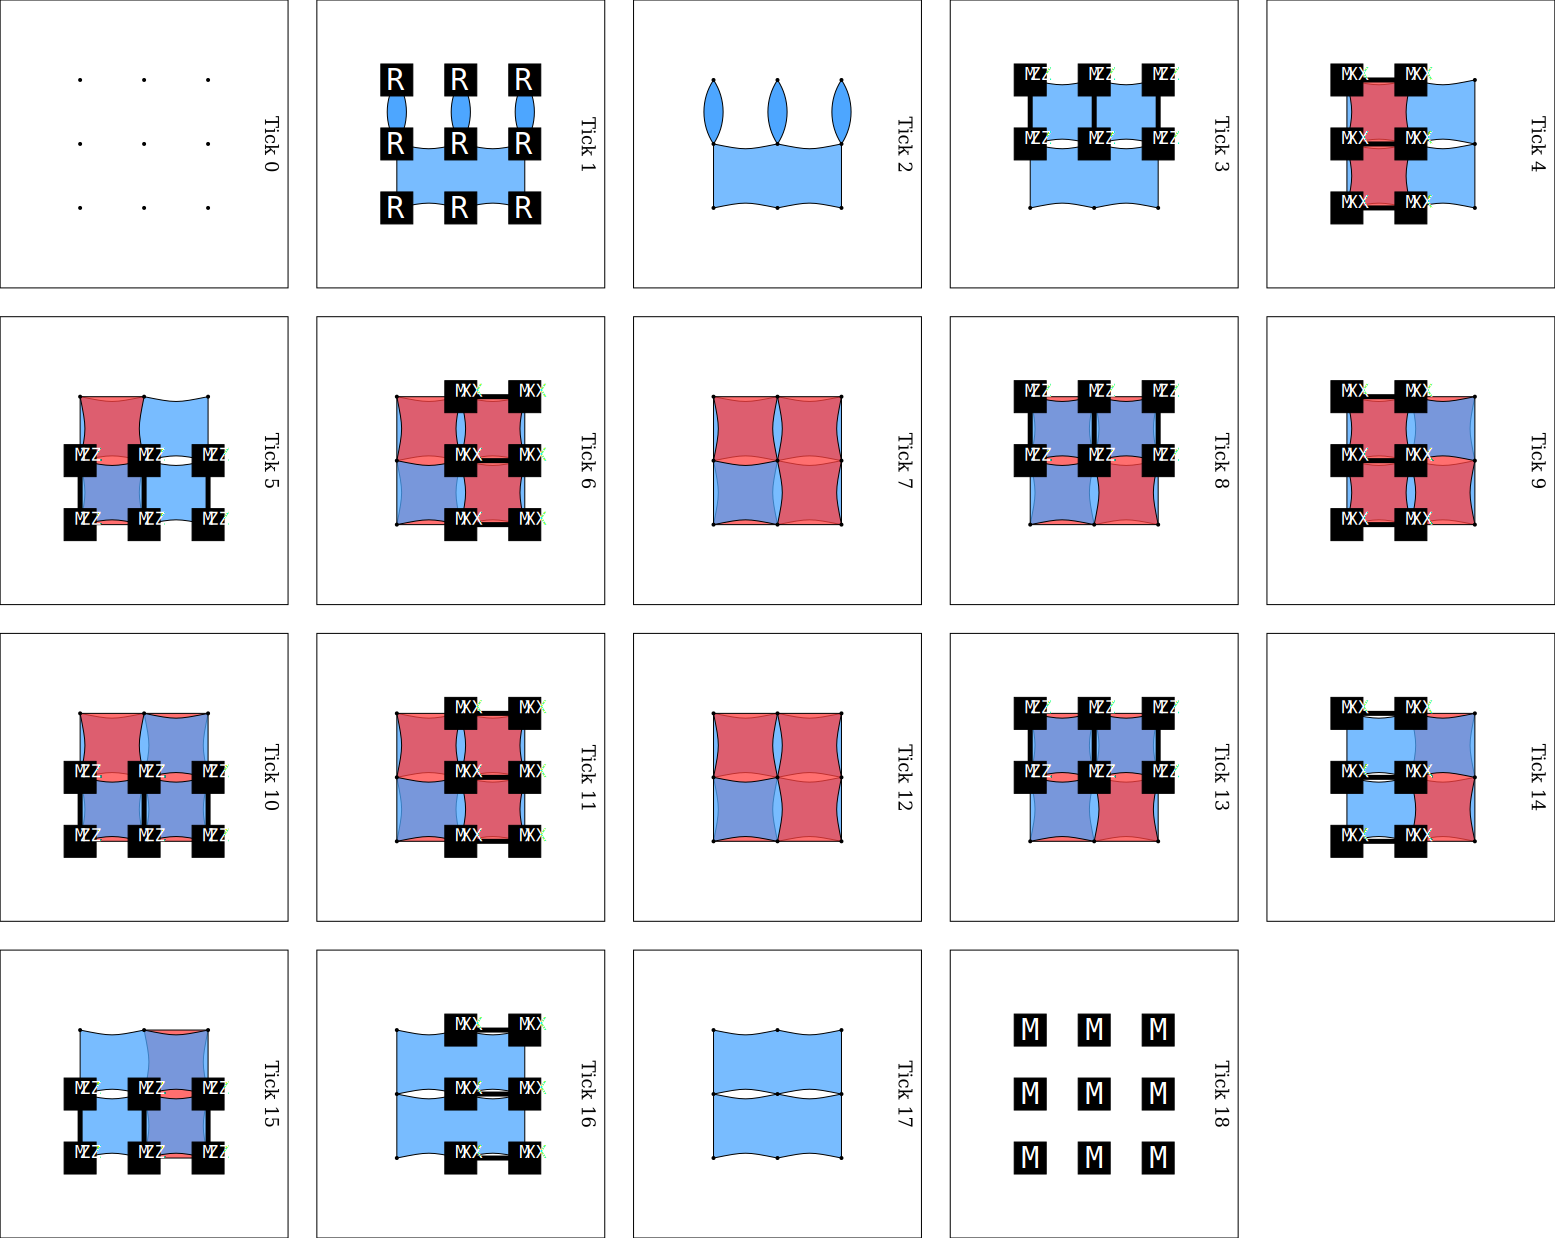

In [41]:
# CELL 6.1: Visualize Bacon-Shor d=3
import stim

print("=== BACON-SHOR d=3 (3x3 Grid) ===")
print("Visualizing the 2D layout of data qubits and gauge measurements.")

# Convert the string defined in Cell 6 into a Stim circuit object
c_d3 = stim.Circuit(circuit_d3_str)

# Display the 2D detector slice diagram with operations
display(c_d3.diagram("detslice-with-ops-svg"))

## 4. Fault-Tolerant State Preparation
In our earlier Steane benchmark, the preparation of the logical \(|0\rangle_L\) state was not fault-tolerant. A single fault during the standard encoding circuit can cascade into a weight-2 error, immediately causing a logical failure for a distance-3 code.

Here, we implement the fault-tolerant state preparation method introduced by Goto (*Sci. Rep. 6, 19578, 2016*). By using a single verification ancilla, we can detect dangerous weight-2 \(X\)-error cascades and post-select them out.

--- Goto Fault-Tolerant Encoder Circuit ---
Prepares logical |0>_L on data qubits 0-6. Qubit 7 is the FT verification ancilla.


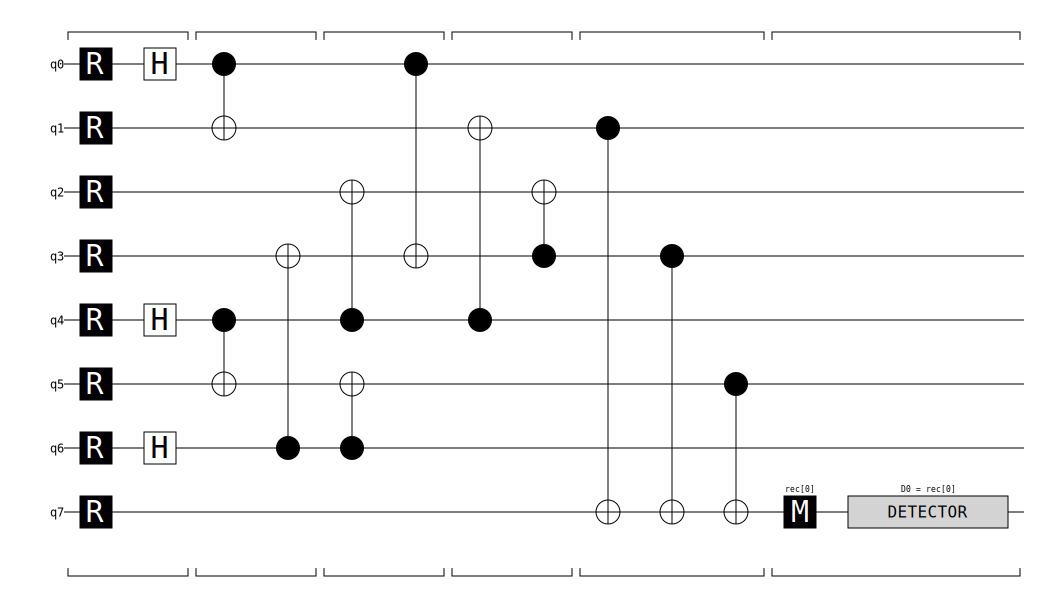

In [53]:
# CELL 7: Fault-Tolerant Goto Encoder for Steane |0>_L (with SVG export)

def build_goto_encoder() -> stim.Circuit:
    """
    Implements Goto's fault-tolerant Steane |0>_L preparation.
    Ref: Sci. Rep. 6, 19578 (2016).
    Uses 1 verification ancilla (q7) to catch weight-2 X errors that
    would otherwise cascade from the encoding CNOTs.
    """
    c = stim.Circuit()
    c.append("R", range(8))

    # Step 1: Prepare |+> on qubits 0, 4, 6
    c.append("H", [0, 4, 6])
    c.append("TICK")

    # Step 2-4: Sequential CNOT layers (ordered to minimize bad propagation)
    c.append("CX", [0, 1, 4, 5, 6, 3])          # Layer 1
    c.append("TICK")

    c.append("CX", [6, 5, 4, 2, 0, 3])          # Layer 2
    c.append("TICK")

    c.append("CX", [4, 1, 3, 2])                # Layer 3
    c.append("TICK")

    # Verification: Measure Z_1 Z_3 Z_5 parity via ancilla 7
    # If ancilla measures 1, a dangerous X-error occurred during encoding
    c.append("CX", [1, 7, 3, 7, 5, 7])
    c.append("TICK")

    c.append("M", [7])

    # Declare the verification measurement as a detector
    # Post-selection will discard shots where this detector fires
    c.append("DETECTOR", [stim.target_rec(-1)])

    return c


# --- Generate and Save SVG Diagram ---
goto_encoder = build_goto_encoder()
diag_goto = goto_encoder.diagram("timeline-svg")

# Save to file for high-res downloading
with open("goto_ft_encoder.svg", "w") as f:
    print(diag_goto, file=f)

print("--- Goto Fault-Tolerant Encoder Circuit ---")
print("Prepares logical |0>_L on data qubits 0-6. Qubit 7 is the FT verification ancilla.")
# Note: 'display' works natively in Jupyter/Colab to render the SVG
display(diag_goto)


### Transversal Bernstein-Vazirani
Applying the same uncorrected transversal approach to the Bernstein-Vazirani algorithm to observe how phase-flip (\(Z\)) errors propagate through the logical oracle.

--- Logical Bernstein-Vazirani Circuit ---
Transversal BV with secret_bit=1


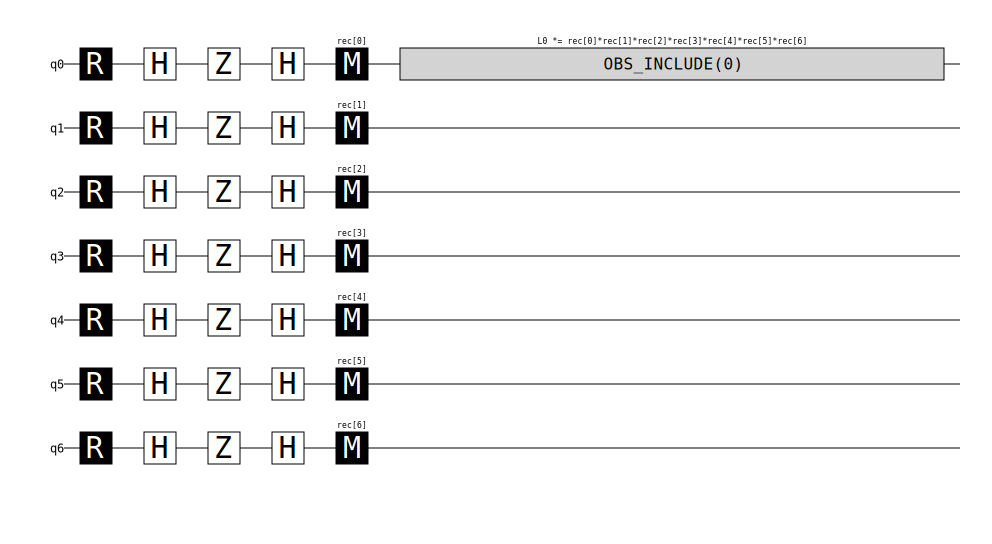


--- Benchmark Results (No EC) ---
Error Rate (Secret=0, 1x Noise):  0.0186
Error Rate (Secret=1, 1x Noise):  0.0197
Error Rate (Secret=1, 10x Noise): 0.1519


In [55]:
# CELL 8: Transversal Bernstein-Vazirani on Steane [[7,1,3]] (Uncorrected)

# Quick demonstration of transversal logical gates on the Steane code.
# Since we aren't extracting syndromes or doing EC between operations here,
# this acts as a baseline to observe raw error amplification.

def build_steane_bv_circuit(secret_bit: int) -> stim.Circuit:
    """
    Prepares |+>_L, applies logical oracle (Z_L), and measures in X-basis.
    Z_L is transversal (Z on all 7 qubits).
    """
    c = stim.Circuit()
    c.append("R", range(7))

    # Prepare logical |+>_L
    c.append("H", range(7))

    # Oracle: apply logical phase flip if secret=1
    if secret_bit == 1:
        c.append("Z", range(7))

    # Measure in logical X basis
    c.append("H", range(7))
    c.append("M", range(7))

    # Logical observable is the X_L parity of all 7 data qubits
    obs_targets = [stim.target_rec(-7 + i) for i in range(7)]
    c.append("OBSERVABLE_INCLUDE", obs_targets, 0)

    return c


# --- Generate and Save SVG Diagram ---
bv_circuit = build_steane_bv_circuit(secret_bit=1)
diag_bv = bv_circuit.diagram("timeline-svg")

with open("logical_bv_circuit.svg", "w") as f:
    print(diag_bv, file=f)

print("--- Logical Bernstein-Vazirani Circuit ---")
print("Transversal BV with secret_bit=1")
display(diag_bv)


# --- Simulation Benchmark ---
def simulate_logical_bv(secret_bit: int, scale: float = 1.0, shots: int = 10_000):
    """Simulate logical BV using the circuit-level noise model defined in Cell 3."""
    c = build_steane_bv_circuit(secret_bit)
    noisy = NoiseModel(scale).apply(c)
    sampler = noisy.compile_sampler()
    samples = sampler.sample(shots=shots)

    # The logical outcome is the collective parity of the 7 X-measurements
    errors = sum(1 for s in samples if (sum(s) % 2) != secret_bit)
    return errors / shots

print("\n--- Benchmark Results (No EC) ---")
print(f"Error Rate (Secret=0, 1x Noise):  {simulate_logical_bv(0, scale=1.0):.4f}")
print(f"Error Rate (Secret=1, 1x Noise):  {simulate_logical_bv(1, scale=1.0):.4f}")
print(f"Error Rate (Secret=1, 10x Noise): {simulate_logical_bv(1, scale=10.0):.4f}")

## 5. Full Fault-Tolerant Memory Benchmark
Finally, we integrate Goto's fault-tolerant state preparation with the multi-round Steane memory cycle.

By filtering out bad initialization shots using the Goto verification detector, we can observe the true performance of the Steane memory cycle. We benchmark this FT-prepared Steane code against the physical qubit baseline to find the effective pseudo-threshold.

--- Goto + Steane Memory (1 round) ---


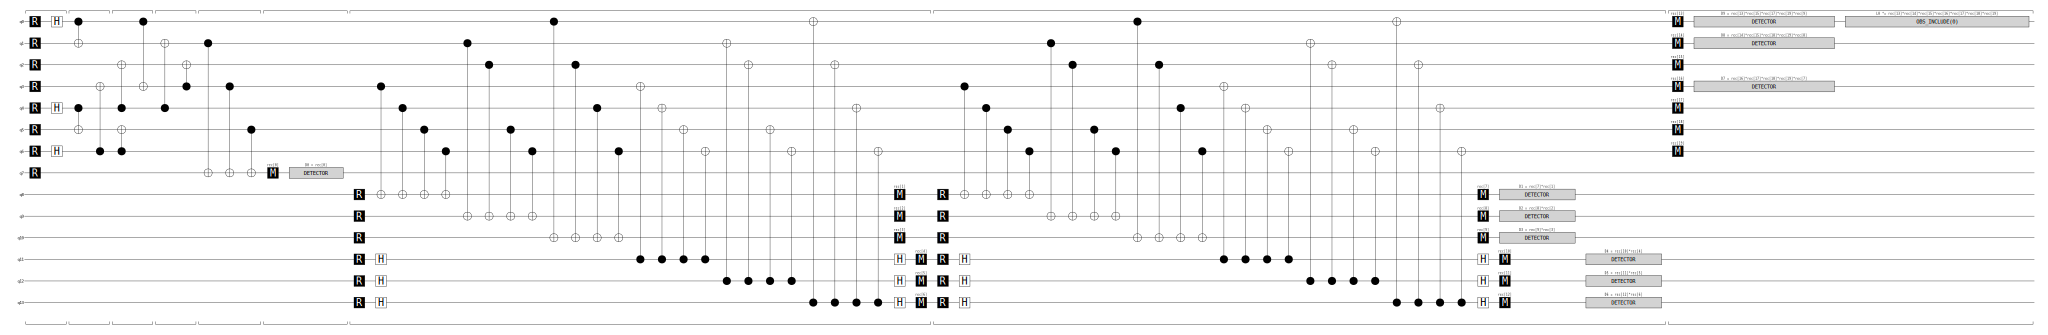


--- Goto + Steane Memory (2 rounds) ---


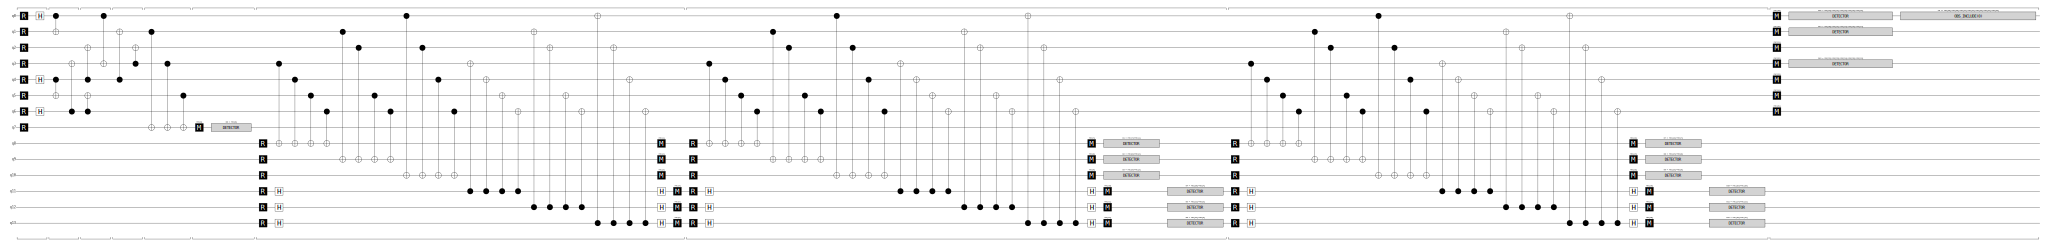

In [56]:
# CELL 9: Goto Preparation + Steane Memory (Multi-Round)

def build_goto_steane_memory(num_rounds: int = 3) -> stim.Circuit:
    """
    Combines Goto's |0>_L preparation with repeated Steane syndrome extraction.
    The first syndrome round is used only to establish a baseline parity.
    """
    c = stim.Circuit()

    # --- 1. Goto FT Encoder ---
    c.append("R", range(8))                       # Data q0-q6, verification q7
    c.append("H", [0, 4, 6])
    c.append("TICK")
    c.append("CX", [0, 1, 4, 5, 6, 3])
    c.append("TICK")
    c.append("CX", [6, 5, 4, 2, 0, 3])
    c.append("TICK")
    c.append("CX", [4, 1, 3, 2])
    c.append("TICK")
    c.append("CX", [1, 7, 3, 7, 5, 7])
    c.append("TICK")
    c.append("M", [7])
    c.append("DETECTOR", [stim.target_rec(-1)])   # Post-selection verification
    c.append("TICK")

    # --- 2. Syndrome Extraction Rounds ---
    # We do num_rounds + 1 total rounds. Round 0 just sets the baseline.
    for r in range(num_rounds + 1):
        c.append("R", [8, 9, 10, 11, 12, 13])
        c.append("H", [11, 12, 13])

        # Z-stabilizers
        c.append("CX", [3,8, 4,8, 5,8, 6,8])
        c.append("CX", [1,9, 2,9, 5,9, 6,9])
        c.append("CX", [0,10, 2,10, 4,10, 6,10])

        # X-stabilizers
        c.append("CX", [11,3, 11,4, 11,5, 11,6])
        c.append("CX", [12,1, 12,2, 12,5, 12,6])
        c.append("CX", [13,0, 13,2, 13,4, 13,6])

        c.append("H", [11, 12, 13])
        c.append("M", [8, 9, 10, 11, 12, 13])

        # Declare detectors only after we have a previous round to compare against
        if r > 0:
            c.append("DETECTOR", [stim.target_rec(-6), stim.target_rec(-12)])
            c.append("DETECTOR", [stim.target_rec(-5), stim.target_rec(-11)])
            c.append("DETECTOR", [stim.target_rec(-4), stim.target_rec(-10)])
            c.append("DETECTOR", [stim.target_rec(-3), stim.target_rec(-9)])
            c.append("DETECTOR", [stim.target_rec(-2), stim.target_rec(-8)])
            c.append("DETECTOR", [stim.target_rec(-1), stim.target_rec(-7)])

        c.append("TICK")

    # --- 3. Final Data Measurement ---
    c.append("M", range(7))

    # Boundary detectors (comparing final data parity to the last syndrome round)
    c.append("DETECTOR", [stim.target_rec(-4), stim.target_rec(-3), stim.target_rec(-2),
                          stim.target_rec(-1), stim.target_rec(-13)])
    c.append("DETECTOR", [stim.target_rec(-6), stim.target_rec(-5), stim.target_rec(-2),
                          stim.target_rec(-1), stim.target_rec(-12)])
    c.append("DETECTOR", [stim.target_rec(-7), stim.target_rec(-5), stim.target_rec(-3),
                          stim.target_rec(-1), stim.target_rec(-11)])

    # Logical observable Z_L
    obs_targets = [stim.target_rec(-7 + i) for i in range(7)]
    c.append("OBSERVABLE_INCLUDE", obs_targets, 0)

    return c

# --- Generate and Save SVG Diagrams ---
diag_goto_mem_1 = build_goto_steane_memory(1).diagram("timeline-svg")
diag_goto_mem_2 = build_goto_steane_memory(2).diagram("timeline-svg")

with open("goto_steane_memory_1_round.svg", "w") as f:
    print(diag_goto_mem_1, file=f)
with open("goto_steane_memory_2_rounds.svg", "w") as f:
    print(diag_goto_mem_2, file=f)

# --- Display Circuit Diagrams Inline ---
print("--- Goto + Steane Memory (1 round) ---")
display(diag_goto_mem_1)

print("\n--- Goto + Steane Memory (2 rounds) ---")
display(diag_goto_mem_2)

--- Starting Goto + Steane Benchmark (3 rounds, 8000 shots) ---

   Scale | Steane Kept | Steane Err | Steane Rate | Phys Rate
-----------------------------------------------------------------
    1.00 |        7843 |        444 |     0.05661 |   0.00550
    3.16 |        7491 |       1273 |     0.16994 |   0.01425
   10.00 |        6647 |       2425 |     0.36483 |   0.05162
   31.62 |        5003 |       2452 |     0.49011 |   0.14100
  100.00 |        3969 |       2007 |     0.50567 |   0.37038


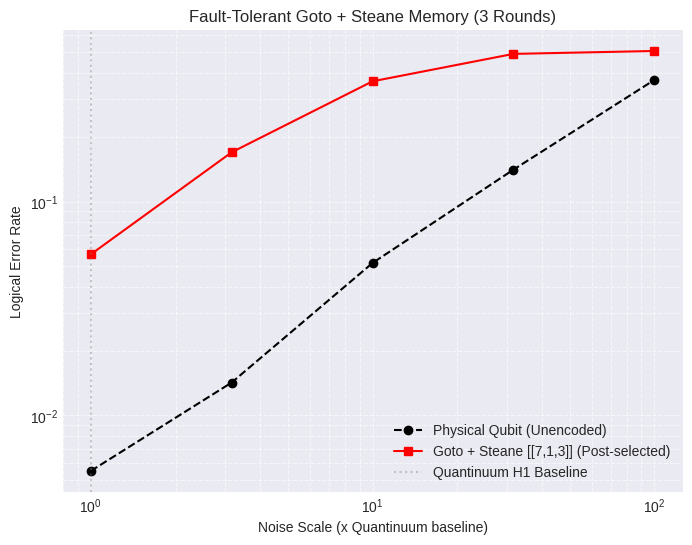


--- Benchmark Finished ---


In [46]:
# CELL 10: Final Benchmark - Goto + Steane vs Physical Qubit

import stim
import pymatching
import numpy as np
import matplotlib.pyplot as plt
import time

def run_goto_memory_benchmark(num_rounds: int = 3, test_shots: int = 8000):
    print(f"--- Starting Goto + Steane Benchmark ({num_rounds} rounds, {test_shots} shots) ---\n")

    scales = np.logspace(0, 2, 5)
    goto_rates = []
    phys_rates = []

    print(f"{'Scale':>8} | {'Steane Kept':>11} | {'Steane Err':>10} | {'Steane Rate':>11} | {'Phys Rate':>9}")
    print("-" * 65)

    for i, scale in enumerate(scales):

        # --- 1. Goto + Steane (with Post-Selection) ---
        c_steane = build_goto_steane_memory(num_rounds)
        noisy_steane = NoiseModel(scale).apply(c_steane)

        sampler_steane = noisy_steane.compile_detector_sampler()
        dets_steane, obs_steane = sampler_steane.sample(shots=test_shots, separate_observables=True)

        # Post-selection: Goto verification detector (index 0) must NOT fire
        good_shots = (dets_steane[:, 0] == 0)
        kept_dets = dets_steane[good_shots]
        kept_obs  = obs_steane[good_shots]

        if len(kept_dets) > 0:
            dem_steane = noisy_steane.detector_error_model()
            matching_steane = pymatching.Matching.from_detector_error_model(dem_steane)
            predictions_steane = matching_steane.decode_batch(kept_dets)

            # Count logical errors
            errors_steane = np.sum(np.any(predictions_steane != kept_obs, axis=1))
            rate_steane = errors_steane / len(kept_dets)
        else:
            errors_steane = 0
            rate_steane = 1.0  # 100% failure if all shots were discarded due to extreme noise

        goto_rates.append(rate_steane)

        # --- 2. Physical Qubit Baseline ---
        # Assuming physical_memory_circuit is defined in Cell 2
        c_phys = physical_memory_circuit(num_rounds)
        noisy_phys = NoiseModel(scale).apply(c_phys)

        sampler_phys = noisy_phys.compile_detector_sampler()
        dets_phys, obs_phys = sampler_phys.sample(shots=test_shots, separate_observables=True)

        dem_phys = noisy_phys.detector_error_model()
        matching_phys = pymatching.Matching.from_detector_error_model(dem_phys)
        predictions_phys = matching_phys.decode_batch(dets_phys)

        errors_phys = np.sum(np.any(predictions_phys != obs_phys, axis=1))
        rate_phys = errors_phys / test_shots
        phys_rates.append(rate_phys)

        # Print row
        print(f"{scale:8.2f} | {len(kept_dets):11d} | {errors_steane:10d} | {rate_steane:11.5f} | {rate_phys:9.5f}")

    # --- Plotting ---
    plt.figure(figsize=(8, 6))
    plt.loglog(scales, phys_rates, 'k--o', label='Physical Qubit (Unencoded)')
    plt.loglog(scales, goto_rates, 'r-s', label=f'Goto + Steane [[7,1,3]] (Post-selected)')

    # Add pseudo-threshold crossover point visually if one exists
    plt.axvline(x=1.0, color='gray', linestyle=':', alpha=0.4, label='Quantinuum H1 Baseline')

    plt.xlabel("Noise Scale (x Quantinuum baseline)")
    plt.ylabel("Logical Error Rate")
    plt.title(f"Fault-Tolerant Goto + Steane Memory ({num_rounds} Rounds)")
    plt.grid(which='both', ls='--', alpha=0.6)
    plt.legend()
    plt.show()

    print("\n--- Benchmark Finished ---")

# --- Run ---
run_goto_memory_benchmark(num_rounds=3, test_shots=8000)